In [8]:
import pandas as pd
from matplotlib import pyplot as plt
import glob
import numpy as np
from matplotlib import colors as mcolors
import colorsys
from matplotlib.patches import Ellipse
from numpy.distutils.conv_template import header
from sklearn.cluster import KMeans
import plotly.express as px
from scipy.spatial.distance import euclidean
import plotly.graph_objects as go

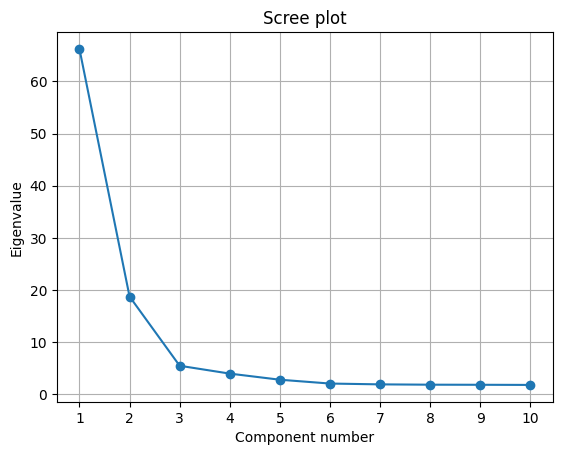

In [28]:
pca_data = pd.read_csv('pca_pruned.eigenvec', sep='\s+', header=None)
pca_data.columns = ['FID', 'IID'] + [f'PC{i}' for i in range(1, pca_data.shape[1] - 1)]
evals = pd.read_csv('pca_pruned.eigenval', header=None)[0]

plt.plot(range(1,11), evals[:10], marker='o')
plt.xticks(range(1, 11))
plt.title('Scree plot')
plt.xlabel('Component number')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

In [29]:
total_var = evals.sum()
var_explained = (evals / total_var) * 100

print("Variance explained by each PC:")
for i, var in enumerate(var_explained, 1):
    print(f"PC{i}: {var:.1f}%")

Variance explained by each PC:
PC1: 61.9%
PC2: 17.6%
PC3: 5.1%
PC4: 3.7%
PC5: 2.6%
PC6: 2.0%
PC7: 1.8%
PC8: 1.8%
PC9: 1.7%
PC10: 1.7%


In [30]:
print("\nCumulative variance explained:")
cum_var = np.cumsum(var_explained)
for i, var in enumerate(cum_var, 1):
    print(f"PC1 to PC{i}: {var:.1f}%")


Cumulative variance explained:
PC1 to PC1: 61.9%
PC1 to PC2: 79.5%
PC1 to PC3: 84.6%
PC1 to PC4: 88.4%
PC1 to PC5: 91.0%
PC1 to PC6: 93.0%
PC1 to PC7: 94.8%
PC1 to PC8: 96.6%
PC1 to PC9: 98.3%
PC1 to PC10: 100.0%


In [31]:
pop_info = {}

for file in glob.glob('*.tsv'):
    df = pd.read_csv(file, sep='\t', header=None)
    for row in df.itertuples(index=False):
        sample = str(row[0]).strip()
        population = str(row[4]).strip()
        pop_info[sample] = population

pca_data['Population'] = pca_data['IID'].map(
    lambda x: pop_info.get(x, 'Kazakh' if str(x).startswith('WE') else 'Unknown')
)

def get_distinct_colors(n, lightness=0.4, saturation=0.8):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lightness, saturation)) for h in hues]

populations = sorted(pca_data['Population'].unique())
color_list = get_distinct_colors(len(populations))
color_dict = dict(zip(populations, color_list))

for pop in populations:
    count = len(pca_data[pca_data['Population'] == pop])
    print(f'{pop}: {count} samples')

Bengali: 86 samples
British: 91 samples
Dai Chinese: 93 samples
Finnish: 99 samples
Gujarati: 100 samples
Han Chinese: 100 samples
Iberian: 100 samples
Japanese: 100 samples
Kazakh: 118 samples
Kinh Vietnamese: 99 samples
Punjabi: 96 samples
Tamil: 100 samples
Toscani: 100 samples


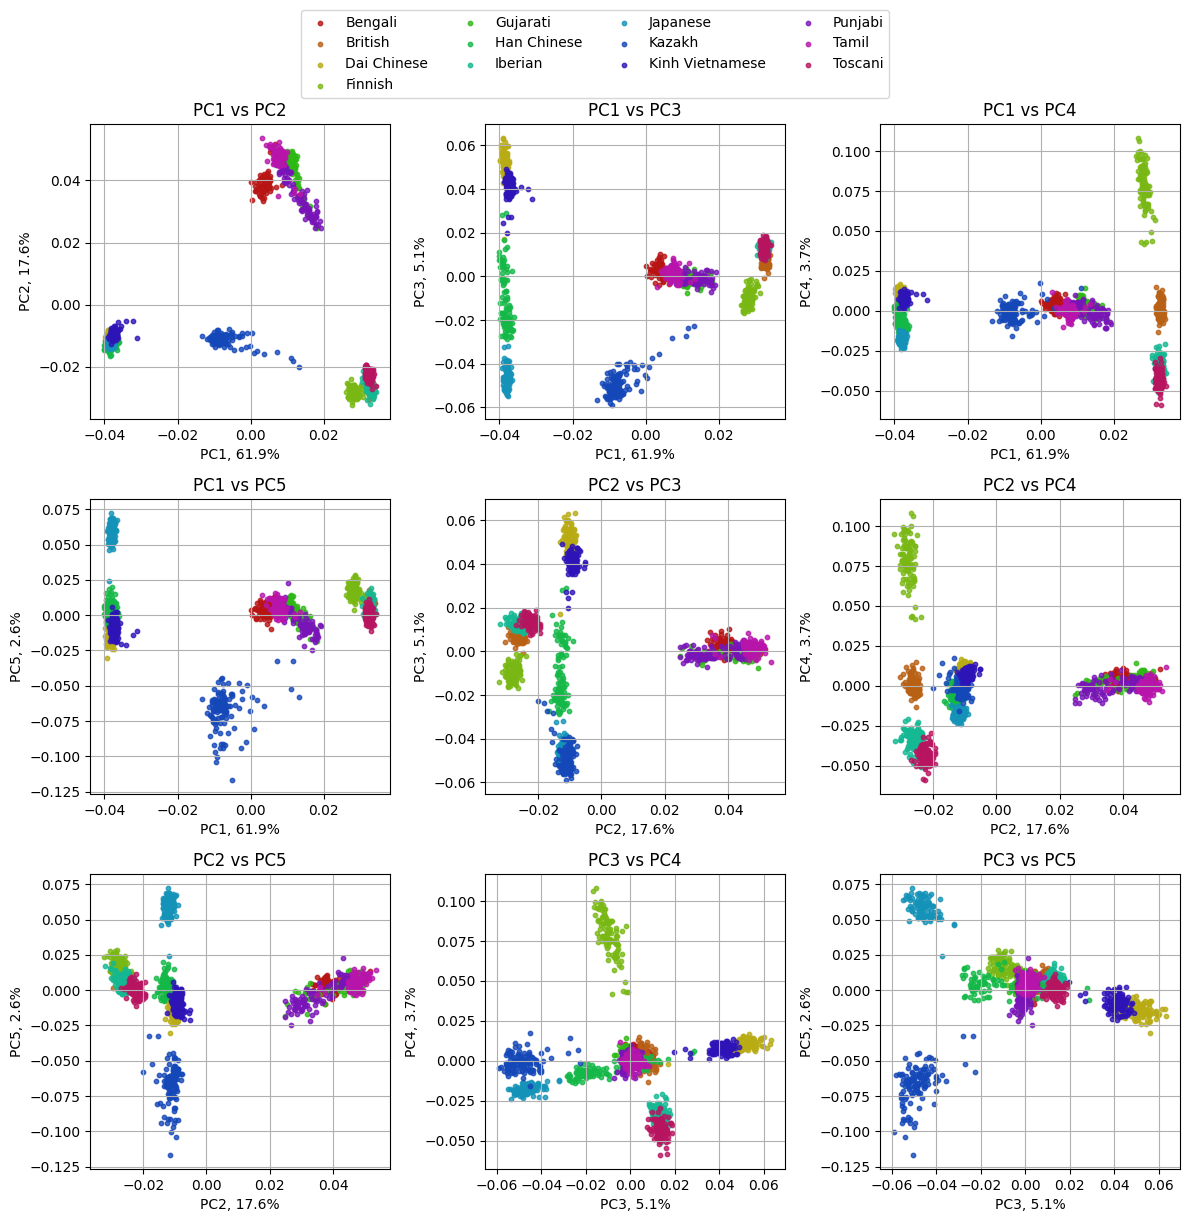

In [32]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
plot_combinations = [(1, 2), (1, 3), (1, 4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5)]

for ax, (x_pc, y_pc) in zip(axs.flatten(), plot_combinations):
    for pop in sorted(pca_data['Population'].unique()):
        subset = pca_data[pca_data['Population'] == pop]
        ax.scatter(
            subset[f'PC{x_pc}'], subset[f'PC{y_pc}'],
            label=pop, color= color_dict[pop], s=10, alpha=0.8)

    ax.set_xlabel(f'PC{x_pc}, {var_explained[(x_pc-1)]:.1f}%')
    ax.set_ylabel(f'PC{y_pc}, {var_explained[(y_pc-1)]:.1f}%')
    ax.set_title(f'PC{x_pc} vs PC{y_pc}')
    ax.grid(True)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
plt.show()

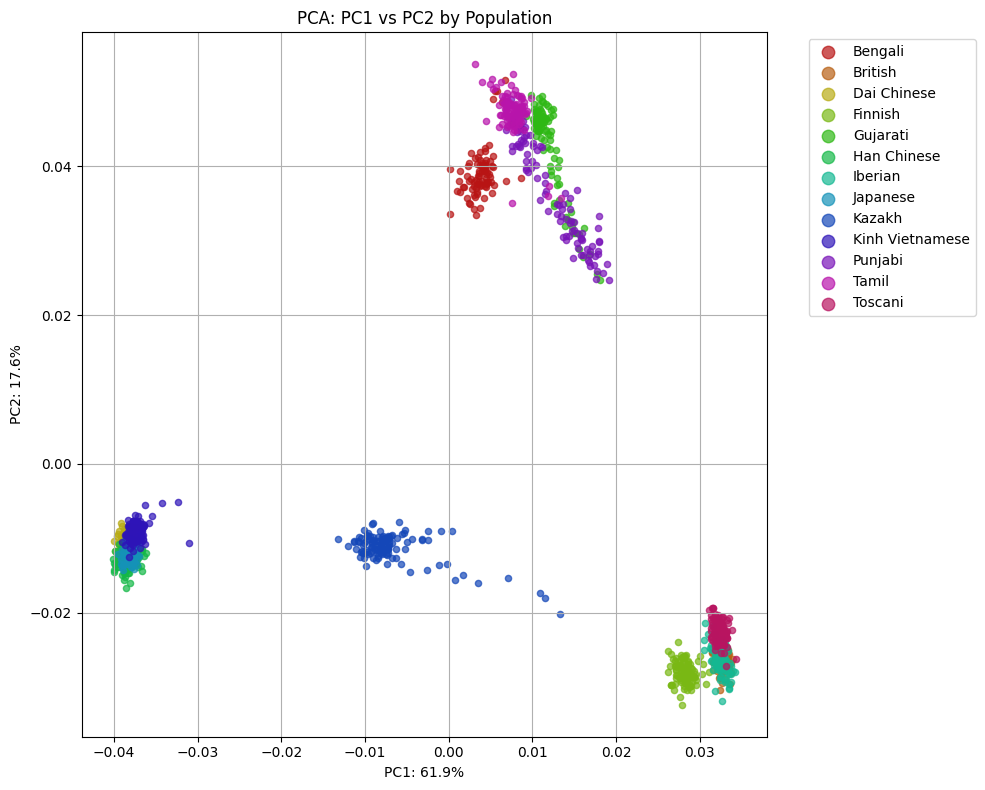

In [33]:
plt.figure(figsize=(10, 8))
for pop in populations:
    subset = pca_data[pca_data['Population'] == pop]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, color=color_dict[pop], label=pop, alpha=0.7)

plt.xlabel(f'PC1: {var_explained[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained[1]:.1f}%')
plt.title('PCA: PC1 vs PC2 by Population')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

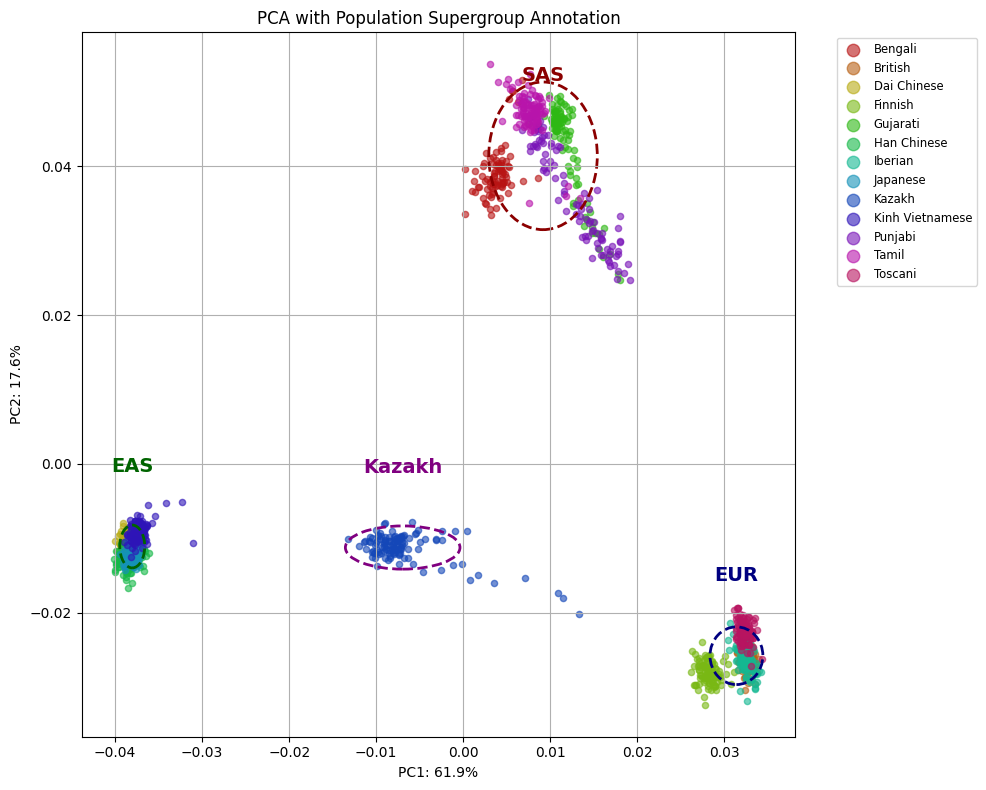

In [34]:
supergroup_map = {
    'EUR': ['Toscani', 'Finnish', 'British', 'Iberian'],
    'SAS': ['Punjabi', 'Gujarati', 'Bengali', 'Tamil'],
    'EAS': ['Han Chinese', 'Kinh Vietnamese', 'Dai Chinese', 'Japanese'],
    'Kazakh': ['Kazakh']}

population_to_supergroup = {pop: sg for sg, pops in supergroup_map.items() for pop in pops}

pca_data['Supergroup'] = pca_data['Population'].map(lambda x: population_to_supergroup.get(x, 'Other'))

plt.figure(figsize=(10, 8))

for pop in populations:
    subset = pca_data[pca_data['Population'] == pop]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, color=color_dict[pop], label=pop, alpha=0.6)

supergroup_colors = {'EUR': 'navy', 'SAS': 'darkred', 'EAS': 'darkgreen', 'Kazakh': 'purple'}
for sg, group_df in pca_data.groupby('Supergroup'):
    if sg == 'Other':
        continue
    pc1 = group_df['PC1']
    pc2 = group_df['PC2']

    width = pc1.std() * 3
    height = pc2.std() * 3
    centroid = (pc1.mean(), pc2.mean())
    ellipse = Ellipse(xy=centroid, width=width, height=height, edgecolor=supergroup_colors[sg],
                      facecolor='none', lw=2, linestyle='--')
    plt.gca().add_patch(ellipse)

    plt.text(centroid[0], centroid[1] + 0.01, sg, fontsize=14, weight='bold',
             color=supergroup_colors[sg], ha='center')

plt.xlabel(f'PC1: {var_explained[0]:.1f}%')
plt.ylabel(f'PC2: {var_explained[1]:.1f}%')
plt.title('PCA with Population Supergroup Annotation')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
for pc in ['PC1', 'PC2', 'PC3']:
    pca_data[pc] = pd.to_numeric(pca_data[pc], errors='coerce')

fig = px.scatter_3d(
    pca_data,
    x='PC1', y='PC2', z='PC3',
    color='Population',
    hover_name='IID',
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(width=900, height=800)
fig.show()


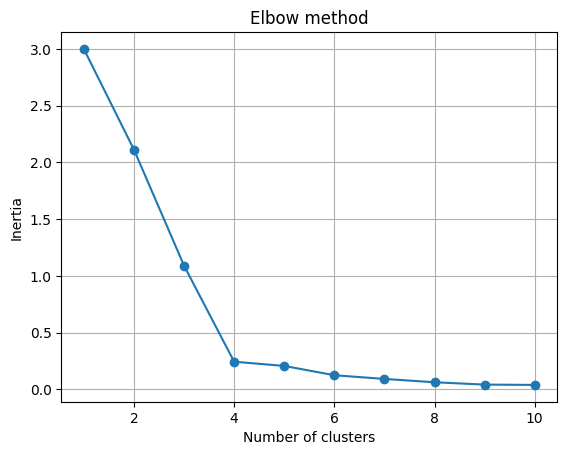

In [39]:
inertias = []
X = pca_data.iloc[:, 2:5]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

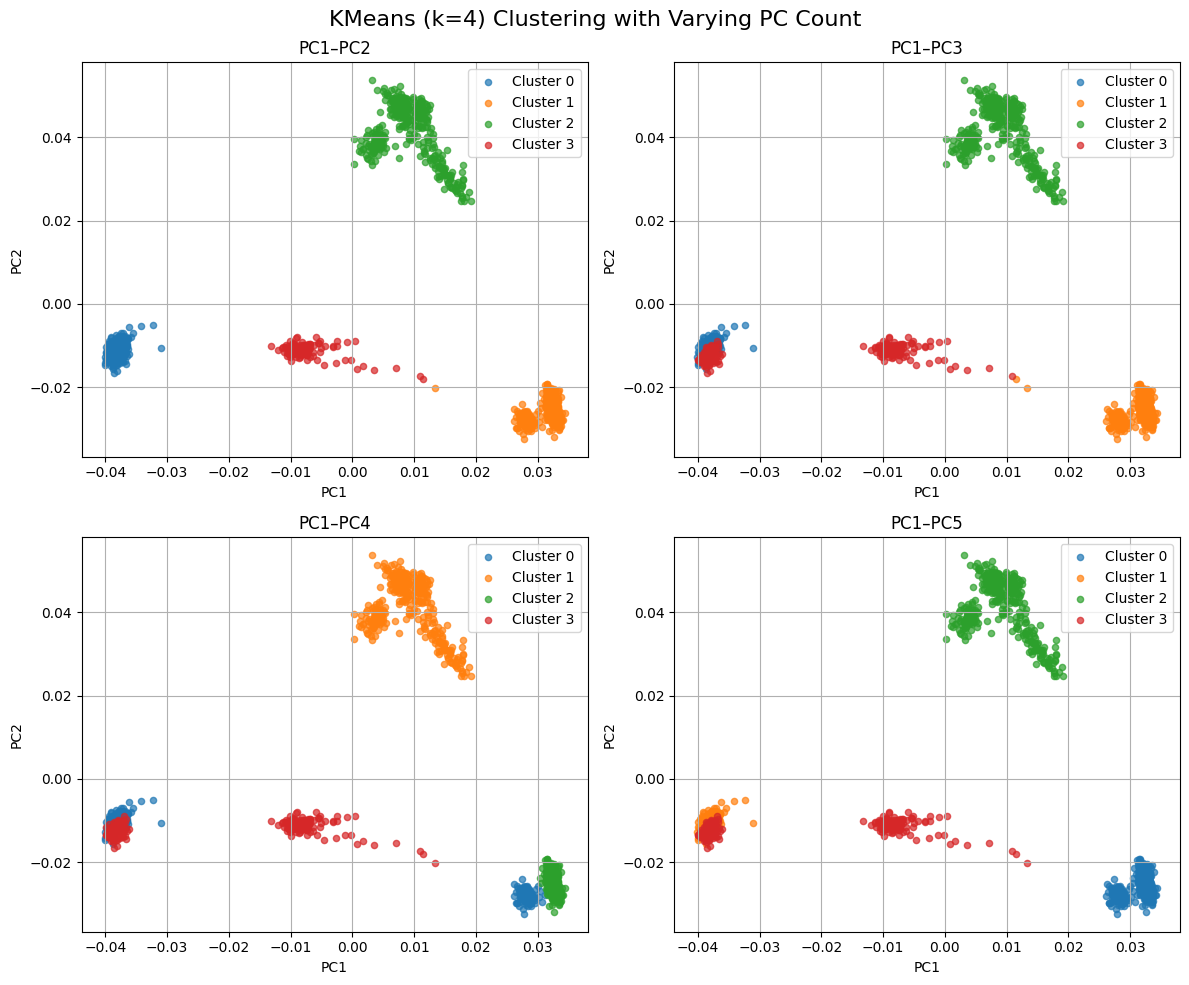

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, i in enumerate(range(2, 6)):
    pcs = [f'PC{j}' for j in range(1, i+1)]
    X = pca_data[pcs]
    kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    ax = axes[idx]

    for c in range(4):
        subset = pca_data[labels == c]
        ax.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

    ax.set_title(f'PC1–PC{i}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
    ax.legend()

plt.suptitle('KMeans (k=4) Clustering with Varying PC Count', fontsize=16)
plt.tight_layout()
plt.show()

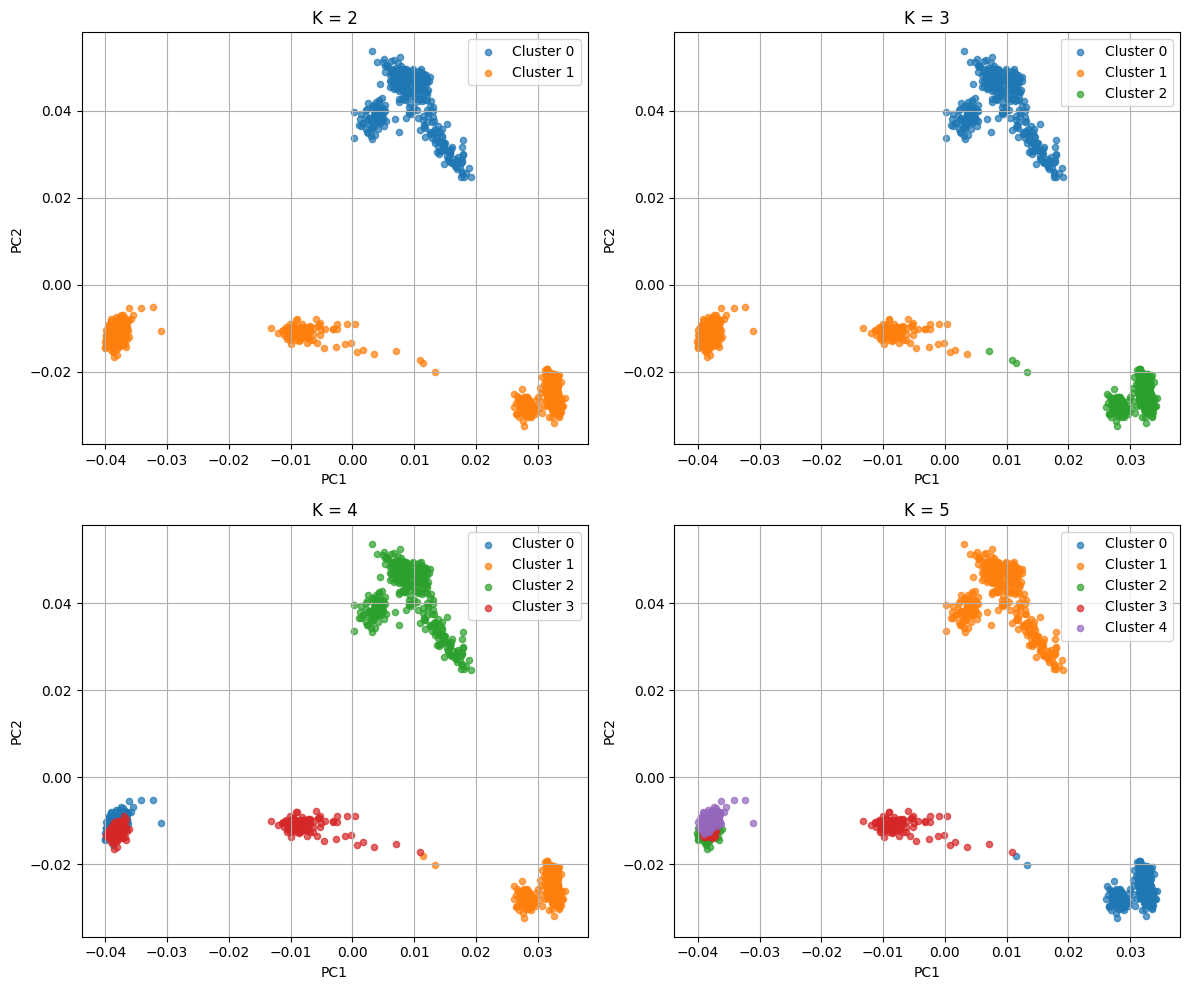

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, i in enumerate(range(2, 6)):
    pcs = [f'PC{j}' for j in range(1, 4)]
    X = pca_data[pcs]

    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    ax = axes[idx]
    for c in range(i):
        subset = pca_data[labels == c]
        ax.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

    ax.set_title(f'K = {i}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Kazakh cluster: 3
Kazakh → Cluster 0: 0.0825
Kazakh → Cluster 1: 0.0744
Kazakh → Cluster 2: 0.0755


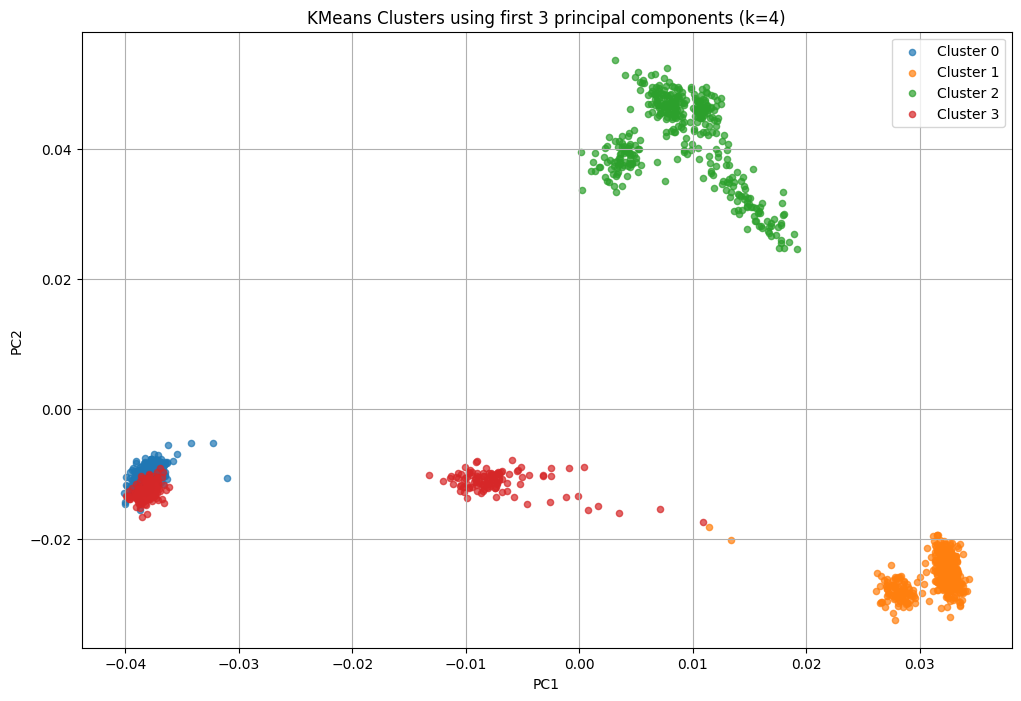

In [42]:
pcs = ['PC1', 'PC2', 'PC3']
X = pca_data[pcs]

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)
pca_data['Cluster'] = labels

kazakh_counts = (pca_data[pca_data['Population'] == 'Kazakh'].groupby('Cluster').size())
kazakh_cluster = kazakh_counts.idxmax()

centroids = pca_data.groupby('Cluster')[pcs].mean()
kazakh_center = centroids.loc[kazakh_cluster]
distances = {}

for cluster_id in centroids.index:
    if cluster_id == kazakh_cluster:
        continue
    other_center = centroids.loc[cluster_id]
    dist = euclidean(kazakh_center, other_center)
    distances[f"Kazakh → Cluster {cluster_id}"] = dist

print(f"Kazakh cluster: {kazakh_cluster}")
for label, dist in distances.items():
    print(f"{label}: {dist:.4f}")

plt.figure(figsize=(12, 8))
for c in range(4):
    subset = pca_data[pca_data['Cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, label=f'Cluster {c}', alpha=0.7)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.title('KMeans Clusters using first 3 principal components (k=4)')
plt.show()


In [46]:
fig = go.Figure()

for cluster_id in centroids.index:
    subset = pca_data[pca_data['Cluster'] == cluster_id]
    fig.add_trace(go.Scatter3d(
        x=subset['PC1'], y=subset['PC2'], z=subset['PC3'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=3),
        opacity=0.6))

for cluster_id, row in centroids.iterrows():
    fig.add_trace(go.Scatter3d(
        x=[row['PC1']], y=[row['PC2']], z=[row['PC3']],
        mode='markers+text',
        name=f'Centroid {cluster_id}',
        marker=dict(size=10, color='black' if cluster_id == kazakh_cluster else 'red'),
        text=[f'C{cluster_id}'],
        textposition='top center'))

for cluster_id, other_center in centroids.iterrows():
    if cluster_id == kazakh_cluster:
        continue
    fig.add_trace(go.Scatter3d(
        x=[kazakh_center['PC1'], other_center['PC1']],
        y=[kazakh_center['PC2'], other_center['PC2']],
        z=[kazakh_center['PC3'], other_center['PC3']],
        mode='lines',
        name=f'Distance to C{cluster_id}',
        line=dict(color='gray', width=2, dash='dash')))

fig.update_layout(title=f'3D PCA with Cluster Centroids (Kazakh = Cluster {kazakh_cluster})',scene=dict(xaxis_title='PC1',yaxis_title='PC2', zaxis_title='PC3'),width=900,height=800)
fig.show()
